# 📉 05-学习率调度与训练策略

> 目标：warmup / cosine / step 调度的**为什么**，以及梯度裁剪、梯度累积、EMA 三个训练技巧的数学原理。

## §1 为什么需要调度

- **前期（warmup）**：训练初期梯度方差大、方向不可信，直接大步长会破坏预训练分布 / 让 loss 炸 → 从小步长线性升到峰值
- **后期（decay）**：接近极小值时步长应缩小才能精细收敛（振荡减小）
- **常用组合**：`linear warmup -> cosine decay`（LLM 标配）、`step decay`（每隔 N 轮 ×0.1）、`exp decay`、`plateau`（loss 停降再减）

$$\text{warmup: } \eta_t = \eta_{max}\frac{t}{T_w}\ (t<T_w)\qquad\text{cosine: } \eta_t = \eta_{min} + \frac{\eta_{max}-\eta_{min}}{2}\left(1+\cos\frac{\pi(t-T_w)}{T-T_w}\right)$$

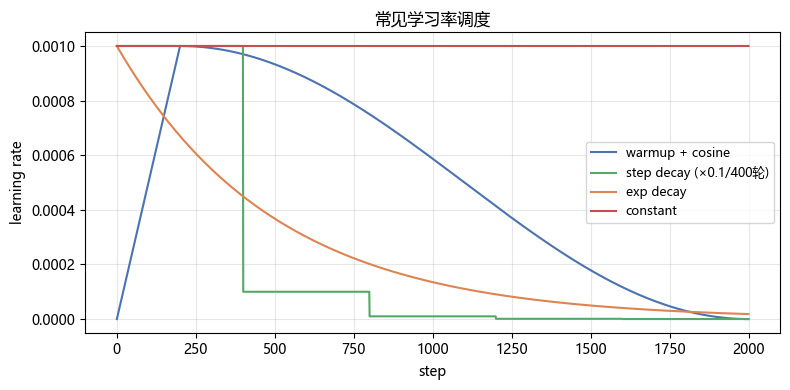

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 实验 1：四种调度曲线 ----------
def schedule(kind, t, T=2000, Tw=200, peak=1e-3):
    if kind == 'warmup_cosine':
        if t < Tw:
            return peak * t / Tw
        return peak * 0.5 * (1 + np.cos(np.pi * (t - Tw) / (T - Tw)))
    if kind == 'step':
        return peak * 0.1 ** (t // 400)
    if kind == 'exp':
        return peak * 0.998 ** t
    if kind == 'constant':
        return peak

ts = np.arange(2000)
fig, ax = plt.subplots(figsize=(8, 4.0))
for kind, col, lab in [('warmup_cosine', '#4C72B0', 'warmup + cosine'),
                       ('step', '#55A868', 'step decay (×0.1/400轮)'),
                       ('exp', '#DD8452', 'exp decay'),
                       ('constant', '#C44E52', 'constant')]:
    ax.plot(ts, [schedule(kind, t) for t in ts], label=lab, color=col, lw=1.5)
ax.set_xlabel('step'); ax.set_ylabel('learning rate')
ax.set_title('常见学习率调度', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

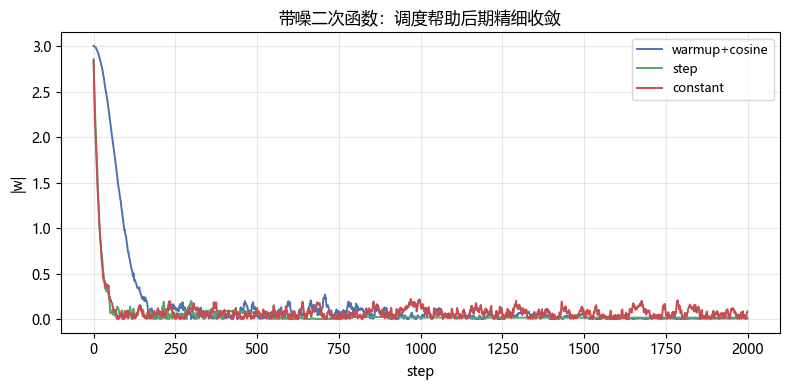

constant 后期在噪声下震荡；warmup+cosine 平滑收敛到更小 |w|


In [2]:
# ---------- 实验 2：不同调度下的收敛对比（简单二次函数 + 噪声） ----------
rng = np.random.default_rng(1)
a = 0.1
f_grad = lambda w: a * w + rng.normal(scale=0.05)

def run(sch, T=2000, Tw=200, peak=0.5):
    w = 3.0; dists = []
    for t in range(T):
        eta = schedule(sch, t, T, Tw, peak)
        w = w - eta * f_grad(w)
        dists.append(abs(w))
    return np.array(dists)

fig, ax = plt.subplots(figsize=(8, 4.0))
for sch, col, lab in [('warmup_cosine', '#4C72B0', 'warmup+cosine'),
                      ('step', '#55A868', 'step'),
                      ('constant', '#C44E52', 'constant')]:
    ax.plot(run(sch), label=lab, color=col, lw=1.4)
ax.set_xlabel('step'); ax.set_ylabel('|w|')
ax.set_title('带噪二次函数：调度帮助后期精细收敛', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('constant 后期在噪声下震荡；warmup+cosine 平滑收敛到更小 |w|')

## §2 梯度裁剪（gradient clipping）

**为什么**：RNN / LLM 的梯度范数可能随步长爆炸（连乘效应）→ 更新过大直接毁掉参数。

$$g \gets g \cdot \min\left(1,\;\frac{\text{max\_norm}}{\|g\|_2}\right)$$

只改方向长度、不改方向；`max_norm` 常用 1.0。PyTorch：`torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)`。

## §3 梯度累积（gradient accumulation）

显存不够跑大 batch 时：小 batch 前向/反向 N 次，**梯度累加后再更新**，等价于 N 倍大 batch（权重更新一次）。

注意：BN / 统计量按小 batch 计算会与真大 batch 有差异；LayerNorm 不受影响（逐 token）→ LLM 常用。

In [3]:
# ---------- 实验 3：梯度裁剪救爆炸 ----------
g_big = np.array([1e4, -3e3, 8e3])
g_clip = g_big * min(1.0, 1.0 / np.linalg.norm(g_big))
print(f'裁剪前 ||g||={np.linalg.norm(g_big):.3e} -> 裁剪后 ||g||={np.linalg.norm(g_clip):.3f}, 方向cos={np.dot(g_big,g_clip)/(np.linalg.norm(g_big)*np.linalg.norm(g_clip)):.6f}')
assert np.isclose(np.linalg.norm(g_clip), 1.0)
print('方向保持：裁剪只改模长不改方向')

裁剪前 ||g||=1.315e+04 -> 裁剪后 ||g||=1.000, 方向cos=1.000000
方向保持：裁剪只改模长不改方向


In [4]:
# ---------- 实验 4：梯度累积 vs 大 batch 等价性 ----------
rng = np.random.default_rng(2)
N, D = 128, 4
X = rng.normal(size=(N, D)); w_true = rng.normal(size=D)
y = X @ w_true + rng.normal(scale=0.1, size=N)

def g_batch(idx):
    r = X[idx] @ w0 - y[idx]
    return X[idx].T @ r / len(idx)

w0 = np.zeros(D)
g_full = g_batch(np.arange(N))            # 128 的全批梯度
g_acc = np.zeros(D)
for s in range(4):                        # 4 × 32 累积
    g_acc += g_batch(np.arange(s * 32, (s + 1) * 32)) / 4
print(f'全批梯度与累积梯度最大差: {np.abs(g_full - g_acc).max():.2e}')
assert np.abs(g_full - g_acc).max() < 1e-14
print('等价性验证通过：4×32 累积 = 1×128 全批（严格平均）')

全批梯度与累积梯度最大差: 3.33e-16
等价性验证通过：4×32 累积 = 1×128 全批（严格平均）


## §4 EMA / SWA（参数滑动平均）

对**参数**做 EMA：$\theta_{ema} \gets \beta \theta_{ema} + (1-\beta)\theta$，推理用 EMA 参数。

作用：权重在多个局部极小间振荡时，EMA 取「质心」→ 更平坦、泛化更好（尤其配合 cosine 退火 = SWA）。

## §5 常见 bug 与面试追问

- **warmup 步数太短**：大模型至少数百步，否则 loss 早期 spike
- **cosine 忘留最小 lr**：降到底会破坏收敛，LLM 常设 `eta_min = peak * 0.1`
- **clip 与 lr 顺序**：先 clip 梯度，再优化器更新
- **梯度累积后忘除以 N**：累积的是和不是均值，步长被放大 N 倍

## §6 自测清单

- [ ] 画四种调度曲线（本文已出图）
- [ ] 默写 warmup 与 cosine 公式
- [ ] 默写梯度裁剪公式并解释方向不变
- [ ] 解释梯度累积为什么等价大 batch（严格平均时）
- [ ] 说清 EMA 为什么提升泛化

> 💡 下节预告：二阶方法（牛顿法/BFGS/K-FAC，06 篇），大模型内存实战（07 篇）。